In [0]:
# 1. read the raw CSV telemetry data
df_telemetry_raw = spark.read.csv("/Volumes/workspace/default/wakeboat_project/wakeboat_telemetry_raw.csv", header=True, inferSchema=True)

In [0]:
# 2. read the raw JSON weather data
df_weather_raw = spark.read.option("multiLine", True).json("/Volumes/workspace/default/wakeboat_project/weather_conditions_raw.json")

In [0]:
# 3. write both out as "bronze" delta tables
df_telemetry_raw.write.format("delta").mode("overwrite").saveAsTable("bronze_wakeboat_telemetry")
df_weather_raw.write.format("delta").mode("overwrite").saveAsTable("bronze_weather_conditions")

In [0]:
# display the data
display(df_telemetry_raw)

timestamp,boat_id,rpm,engine_temp_f,ballast_weight_lbs,error_code
2025-03-01T00:00:00.000Z,GatorWake_MasterCraft_2,3029.0,165.2871538743342,1500,null
2025-03-01T00:15:00.000Z,GatorWake_Nautique_1,3272.0,174.83887331291697,0,null
2025-03-01T00:30:00.000Z,GatorWake_Nautique_1,3492.0,161.03175043087597,0,null
2025-03-01T00:45:00.000Z,GatorWake_MasterCraft_2,2466.0,164.99057934770684,1500,null
2025-03-01T01:00:00.000Z,GatorWake_MasterCraft_2,4132.0,165.4275053156416,3000,null
2025-03-01T01:15:00.000Z,GatorWake_MasterCraft_2,2953.0,152.07912953029023,3000,null
2025-03-01T01:30:00.000Z,GatorWake_MasterCraft_2,3472.0,157.80241786092313,1500,null
2025-03-01T01:45:00.000Z,GatorWake_Nautique_1,3859.0,163.10164190235724,2500,null
2025-03-01T02:00:00.000Z,GatorWake_Nautique_1,3594.0,173.70525118496738,0,null
2025-03-01T02:15:00.000Z,GatorWake_MasterCraft_2,3458.0,162.03895173826803,2500,null


In [0]:
from pyspark.sql.functions import col, expr

In [0]:
# 1. load the raw bronze data
df_telemetry = spark.read.table("bronze_wakeboat_telemetry")
df_weather = spark.read.table("bronze_weather_conditions")

In [0]:
# 2. clean the telemetry data
df_telemetry_clean = df_telemetry.dropna(subset=["rpm"])

In [0]:
# 3. clean the weather data (FIXED)
# using try_cast so malformed text like "SENSOR_ERROR" becomes null instead of crashing the pipeline
df_weather_clean = df_weather.select(
    col("datetime").cast("timestamp").alias("weather_time"),
    expr("try_cast(measurements.wind_speed_mph as float)").alias("wind_speed"),
    expr("try_cast(measurements.wind_direction_deg as int)").alias("wind_dir"),
    expr("try_cast(measurements.air_temp_f as float)").alias("air_temp")
).dropna() 

In [0]:
# 4. join the datasets into a single operational view
df_silver = df_telemetry_clean.join(
    df_weather_clean,
    df_telemetry_clean.timestamp == df_weather_clean.weather_time,
    "inner"
).drop("weather_time")

In [0]:
# 5. save as our clean silver delta table
df_silver.write.format("delta").mode("overwrite").saveAsTable("silver_wakeboat_operations")

In [0]:
# display new silver data
display(df_silver)

timestamp,boat_id,rpm,engine_temp_f,ballast_weight_lbs,error_code,wind_speed,wind_dir,air_temp
2025-03-01T00:00:00.000Z,GatorWake_MasterCraft_2,3029.0,165.2871538743342,1500,null,2.9,207,75.6
2025-03-01T00:15:00.000Z,GatorWake_Nautique_1,3272.0,174.83887331291697,0,null,7.0,148,76.1
2025-03-01T00:30:00.000Z,GatorWake_Nautique_1,3492.0,161.03175043087597,0,null,2.0,202,76.2
2025-03-01T00:45:00.000Z,GatorWake_MasterCraft_2,2466.0,164.99057934770684,1500,null,0.0,145,61.9
2025-03-01T01:00:00.000Z,GatorWake_MasterCraft_2,4132.0,165.4275053156416,3000,null,2.2,259,68.4
2025-03-01T01:15:00.000Z,GatorWake_MasterCraft_2,2953.0,152.07912953029023,3000,null,2.7,342,74.0
2025-03-01T01:30:00.000Z,GatorWake_MasterCraft_2,3472.0,157.80241786092313,1500,null,3.5,65,76.9
2025-03-01T01:45:00.000Z,GatorWake_Nautique_1,3859.0,163.10164190235724,2500,null,2.4,280,62.6
2025-03-01T02:00:00.000Z,GatorWake_Nautique_1,3594.0,173.70525118496738,0,null,0.0,166,69.7
2025-03-01T02:15:00.000Z,GatorWake_MasterCraft_2,3458.0,162.03895173826803,2500,null,0.0,137,79.2


In [0]:
from pyspark.sql.functions import col, when

In [0]:

# 1. load the clean silver data
df_silver = spark.read.table("silver_wakeboat_operations")

In [0]:
# 2. feature engineering: create business metrics for the ML model
df_gold = df_silver.withColumn(
    "wind_chop_index",
    # categorize wind into chop levels
    when(col("wind_speed") > 15, "High")
    .when(col("wind_speed") > 8, "Moderate")
    .otherwise("Low")
).withColumn(
    "engine_stress_flag",
    # flag instances where the engine is running hot under high RPMs
    when((col("engine_temp_f") > 180) & (col("rpm") > 3500), 1)
    .otherwise(0)
).withColumn(
    "optimal_riding_conditions",
    # our target variable for the ML model: Warm air and low chop!
    when((col("wind_chop_index") == "Low") & (col("air_temp") > 70), 1)
    .otherwise(0)
)

In [0]:
# 3. save as the final gold delta table
df_gold.write.format("delta").mode("overwrite").saveAsTable("gold_wakeboat_ml_features")

In [0]:
# display new gold data
display(df_gold)

timestamp,boat_id,rpm,engine_temp_f,ballast_weight_lbs,error_code,wind_speed,wind_dir,air_temp,wind_chop_index,engine_stress_flag,optimal_riding_conditions
2025-03-01T00:00:00.000Z,GatorWake_MasterCraft_2,3029.0,165.2871538743342,1500,null,2.9,207,75.6,Low,0,1
2025-03-01T00:15:00.000Z,GatorWake_Nautique_1,3272.0,174.83887331291697,0,null,7.0,148,76.1,Low,0,1
2025-03-01T00:30:00.000Z,GatorWake_Nautique_1,3492.0,161.03175043087597,0,null,2.0,202,76.2,Low,0,1
2025-03-01T00:45:00.000Z,GatorWake_MasterCraft_2,2466.0,164.99057934770684,1500,null,0.0,145,61.9,Low,0,0
2025-03-01T01:00:00.000Z,GatorWake_MasterCraft_2,4132.0,165.4275053156416,3000,null,2.2,259,68.4,Low,0,0
2025-03-01T01:15:00.000Z,GatorWake_MasterCraft_2,2953.0,152.07912953029023,3000,null,2.7,342,74.0,Low,0,1
2025-03-01T01:30:00.000Z,GatorWake_MasterCraft_2,3472.0,157.80241786092313,1500,null,3.5,65,76.9,Low,0,1
2025-03-01T01:45:00.000Z,GatorWake_Nautique_1,3859.0,163.10164190235724,2500,null,2.4,280,62.6,Low,0,0
2025-03-01T02:00:00.000Z,GatorWake_Nautique_1,3594.0,173.70525118496738,0,null,0.0,166,69.7,Low,0,0
2025-03-01T02:15:00.000Z,GatorWake_MasterCraft_2,3458.0,162.03895173826803,2500,null,0.0,137,79.2,Low,0,1


In [0]:
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [0]:
# 1. convert our gold delta table to a pandas DataFrame for ML training
df_gold_pd = spark.read.table("gold_wakeboat_ml_features").toPandas()

In [0]:
# 2. select our features (X) and target (y)
# we want the model to look at the engine and weather to predict riding conditions
features = ["rpm", "engine_temp_f", "wind_speed", "air_temp"]
X = df_gold_pd[features]
y = df_gold_pd["optimal_riding_conditions"]

# split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [0]:
# 3. start MLflow tracking!
with mlflow.start_run(run_name="Wakeboat_Conditions_Predictor"):
    
    # set our model "knobs" (hyperparameters)
    trees = 100
    depth = 5
    
    # log these parameters to MLflow so we don't forget them
    mlflow.log_param("n_estimators", trees)
    mlflow.log_param("max_depth", depth)
    
    # train the random forest model
    model = RandomForestClassifier(n_estimators=trees, max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    
    # test the model and see how accurate it is
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    
    # log the final accuracy score to MLflow
    mlflow.log_metric("accuracy", accuracy)
    
    # save the actual trained model into the MLflow registry
    mlflow.sklearn.log_model(model, "random_forest_model")
    
    print(f"Model trained successfully! Accuracy: {accuracy:.2f}")
    print("Experiment logged to MLflow.")

2026/10/07 00:14:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-86efa1de-713c.cloud.databricks.com/ml/experiments/1841428633327289/models/m-23701714da4242ff9e59f6137ddbbe84?o=7474653460642884
2026/10/07 00:14:21 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.12.0/ml/model/signatures.html for instructions on setting signature on models.


Model trained successfully! Accuracy: 1.00
Experiment logged to MLflow.


In [0]:
# %pip install shap
import shap
import matplotlib.pyplot as plt

In [0]:
# 1. initialize the SHAP explainer with our trained Random Forest model
explainer = shap.TreeExplainer(model)

In [0]:
# 2. calculate the SHAP values using our test data
shap_values = explainer.shap_values(X_test)

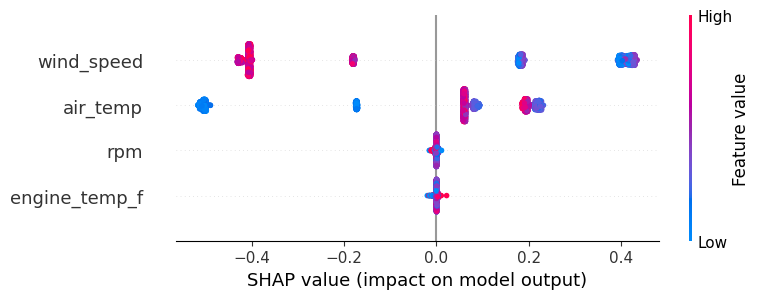

In [0]:
# 3. generate a summary plot for the "optimal conditions" target
plt.figure(figsize=(8, 5))
# FIX: Use [:, :, 1] to properly slice the 3D array for the positive class in newer SHAP versions
shap.summary_plot(shap_values[:, :, 1], X_test, show=False)

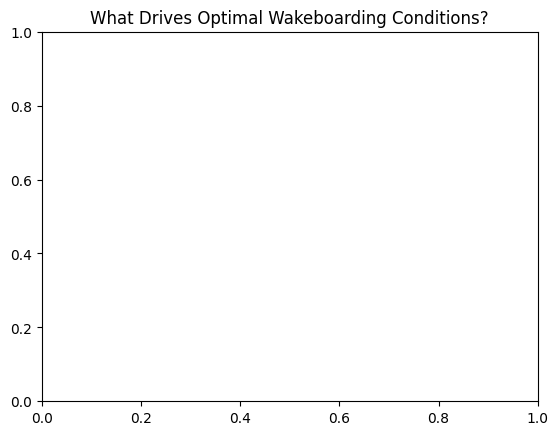

In [0]:
# display plot in Databricks
plt.title("What Drives Optimal Wakeboarding Conditions?")
plt.show()